# Model 4: Random Forest: Coral Reef Regime Classification

Reproduces the **Random Forest with engineered features** (the paper's best model: train 1.00 / val 0.70 / test 0.70) from *"Predicting Coral Reef Regimes from Human and Natural Influences"* (Walecka, Murphy, Cheng, CS 229).

**Protocol (same as the paper):**
- Fixed 80/20 split → train+val = 496 rows, test = 124 rows (test used **once**, at the end)
- 5-fold CV on the 496 training rows for validation scores and tuning
- Metric: micro-averaged F1 (we also report macro-F1 and per-class recall)

**Contents**
1. Load data
2. Baseline forest (default settings), original vs. engineered features
3. Grid search with 5-fold CV
4. Validation curves and OOB check
5. Feature importances (impurity and permutation)
6. One-shot test evaluation and error analysis
7. Summary against the paper

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                             classification_report, recall_score)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 229
CLASS_NAMES = ["Reg 1", "Reg 2", "Reg 3", "Reg 5"]

## 1. Load data
The repo ships imputed ("complete") data, the 5 engineered features, and a fixed split. The authors' 100-row val split is merged back into train (396 + 100 = 496) because CV replaces it.

In [2]:
BASE = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Modeling/"
FILES = {"train": "Predictors_complete_train.txt",
         "val":   "Predictors_complete_val.txt",
         "test":  "Predictors_complete_test.txt"}

def read_split(name):
    local = os.path.join("..", "Data", "Modeling", FILES[name])
    path = local if os.path.exists(local) else BASE + FILES[name]
    df = pd.read_csv(path, sep="\t", decimal=",")
    return df.drop(df.columns[[0, 1]], axis=1)

train_raw, val_raw, test_raw = (read_split(s) for s in ["train", "val", "test"])
train = pd.concat([train_raw, val_raw], ignore_index=True)
test = test_raw.copy()
print("train+val:", train.shape, "| test:", test.shape, "| NAs in train:", int(train.isna().sum().sum()))

ORIG_FEATURES = ["Effluent","Sedimentation","New_Development","Habitat_Modification","Invasive_Algae",
                 "Fishing_Comm_Total","Fishing_NonComm_Boat_Total","Fishing_NonComm_Shore_Line",
                 "Fishing_NonComm_Shore_Net","Fishing_NonComm_Shore_Spear",
                 "SST_CLIM_M","SST_STD","CHL_CLIM_M","CHL_ANOM_F","PAR_CLIM_M","PAR_STD",
                 "WAV_CLIM_M","WAV_ANOM_F","Complexity","Depth"]
ENG_FEATURES  = ["sqrt_power_x_compexity","log_power_over_depth","complexity_over_depth",
                 "Irradiance_x_inv_algae","both_anomolies"]
ALL_FEATURES = ORIG_FEATURES + ENG_FEATURES

get_xy = lambda df, f: (df[f].astype(float), df["Regime"].astype(int))
X_tr_orig, y_tr = get_xy(train, ORIG_FEATURES)
X_tr_all,  _    = get_xy(train, ALL_FEATURES)
X_te_orig, y_te = get_xy(test,  ORIG_FEATURES)
X_te_all,  _    = get_xy(test,  ALL_FEATURES)
print("Features: %d original, %d with engineered" % (X_tr_orig.shape[1], X_tr_all.shape[1]))

train+val: (496, 44) | test: (124, 44) | NAs in train: 0
Features: 20 original, 25 with engineered


## 2. Evaluation helpers
For single-label multiclass problems, **micro-F1 equals accuracy**. The paper's claim that it handles class imbalance is not accurate, so we also track macro-F1 and per-class recall (especially Regime 1, the "degraded" reef).

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"micro_f1": "f1_micro", "macro_f1": "f1_macro"}

def cv_report(model, X, y, label):
    r = cross_validate(model, X, y, cv=cv, scoring=SCORING, return_train_score=True, n_jobs=-1)
    return {"Model": label,
            "Train micro-F1": r["train_micro_f1"].mean(),
            "Val micro-F1":   r["test_micro_f1"].mean(),
            "Val std":        r["test_micro_f1"].std(),
            "Val macro-F1":   r["test_macro_f1"].mean()}

def plot_cm(y_true, y_pred, title):
    cm = pd.DataFrame(confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 5]),
                      index=CLASS_NAMES, columns=CLASS_NAMES)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="g", cmap="YlGnBu")
    plt.title(title); plt.ylabel("Actual label"); plt.xlabel("Predicted label")
    plt.tight_layout(); plt.show()

## 3. Baseline: default Random Forest
100 fully grown trees, no tuning. Fully grown trees give a training score of about 1.00, which matches the paper's Random Forest train F1.

In [4]:
default_rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
results = [cv_report(default_rf, X_tr_orig, y_tr, "Default RF (orig. features)"),
           cv_report(default_rf, X_tr_all,  y_tr, "Default RF (+ engineered features)")]
pd.DataFrame(results).round(3)

,Model,Train micro-F1,Val micro-F1,Val std,Val macro-F1
0,Default RF (orig. features),1.0,0.679,0.045,0.676
1,Default RF (+ engineered features),1.0,0.679,0.039,0.675


## 4. Tune with 5-fold CV
We search `n_estimators`, `max_depth`, `min_samples_leaf` and `max_features`, selecting on micro-F1. The `min_samples_leaf` and `max_features` options go beyond the authors' grid (trees and depth only) and directly address the overfitting.

In [5]:
param_grid = {
    "n_estimators":     [100, 250],
    "max_depth":        [4, 6, 8, None],
    "min_samples_leaf": [1, 3],
    "max_features":     ["sqrt", 0.5],
}

def tune(X, y):
    gs = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), param_grid,
                      cv=cv, scoring="f1_micro", return_train_score=True, n_jobs=-1)
    return gs.fit(X, y)

gs_orig = tune(X_tr_orig, y_tr)
gs_all  = tune(X_tr_all,  y_tr)
for name, gs in [("Original features", gs_orig), ("+ Engineered features", gs_all)]:
    print(f"{name:22s} best CV micro-F1 = {gs.best_score_:.3f} | {gs.best_params_}")

Original features      best CV micro-F1 = 0.692 | {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 100}
+ Engineered features  best CV micro-F1 = 0.679 | {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}


In [6]:
results += [cv_report(gs_orig.best_estimator_, X_tr_orig, y_tr, "Tuned RF (orig. features)"),
            cv_report(gs_all.best_estimator_,  X_tr_all,  y_tr, "Tuned RF (+ engineered features)")]
comparison = pd.DataFrame(results).round(3)
comparison

,Model,Train micro-F1,Val micro-F1,Val std,Val macro-F1
0,Default RF (orig. features),1.000,0.679,0.045,0.676
1,Default RF (+ engineered features),1.000,0.679,0.039,0.675
2,Tuned RF (orig. features),0.986,0.692,0.050,0.687
3,Tuned RF (+ engineered features),1.000,0.679,0.039,0.675


**Reading the table:** a train F1 near 1.00 with validation around 0.65-0.70 means the forest memorizes the training data and still generalizes reasonably, which is typical for a Random Forest. Compare validation scores against the **Val std** column. Gaps smaller than about one std are noise at this sample size.

## 5. Validation curves
How validation F1 responds to forest size and tree depth, all other hyperparameters held at the selected values.

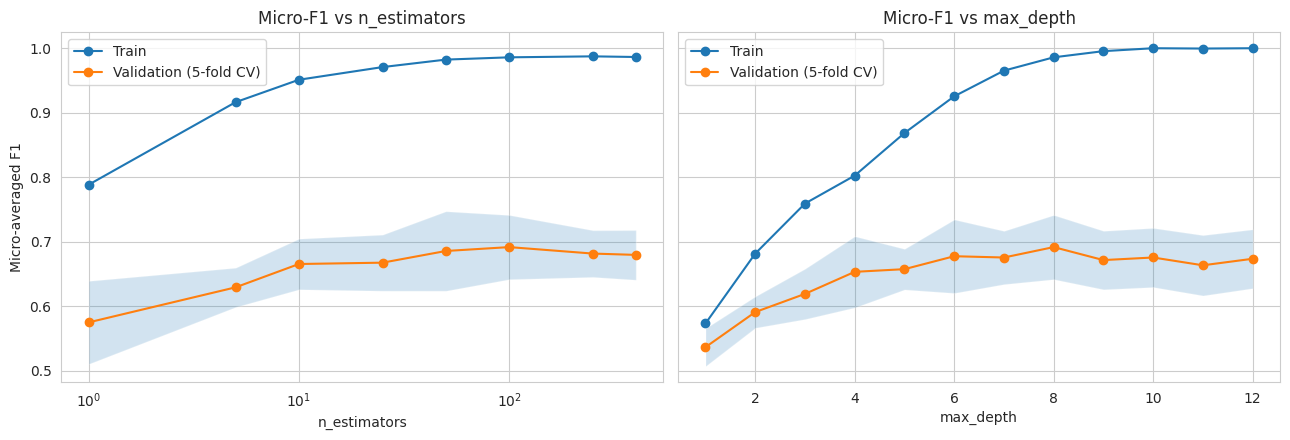

In [7]:
best_params = (gs_all if gs_all.best_score_ >= gs_orig.best_score_ else gs_orig).best_params_
X_curve = X_tr_all if gs_all.best_score_ >= gs_orig.best_score_ else X_tr_orig

def curve(param, values):
    tr_s, va_s, va_sd = [], [], []
    for v in values:
        p = {**best_params, param: v}
        r = cross_validate(RandomForestClassifier(random_state=RANDOM_STATE, **p), X_curve, y_tr,
                           cv=cv, scoring="f1_micro", return_train_score=True, n_jobs=-1)
        tr_s.append(r["train_score"].mean()); va_s.append(r["test_score"].mean()); va_sd.append(r["test_score"].std())
    return np.array(tr_s), np.array(va_s), np.array(va_sd)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (param, vals) in zip(axes, [("n_estimators", [1, 5, 10, 25, 50, 100, 250, 400]),
                                    ("max_depth", list(range(1, 13)))]):
    tr_s, va_s, va_sd = curve(param, vals)
    ax.plot(vals, tr_s, "o-", label="Train")
    ax.plot(vals, va_s, "o-", label="Validation (5-fold CV)")
    ax.fill_between(vals, va_s - va_sd, va_s + va_sd, alpha=0.2)
    ax.set_xlabel(param); ax.set_title(f"Micro-F1 vs {param}"); ax.legend()
axes[0].set_ylabel("Micro-averaged F1")
axes[0].set_xscale("log")
plt.tight_layout(); plt.show()

## 6. Choose the final model
We pick whichever tuned variant has the higher CV micro-F1. The test set is still untouched. We also report the **out-of-bag (OOB) score**, a free internal validation estimate that should be close to the CV score.

In [8]:
if gs_all.best_score_ >= gs_orig.best_score_:
    final_name, final_gs, X_tr_final, X_te_final, feats = "Tuned RF (+ engineered features)", gs_all, X_tr_all, X_te_all, ALL_FEATURES
else:
    final_name, final_gs, X_tr_final, X_te_final, feats = "Tuned RF (orig. features)", gs_orig, X_tr_orig, X_te_orig, ORIG_FEATURES

print("Selected:", final_name)
print("Params:  ", final_gs.best_params_)
print("CV micro-F1: %.3f" % final_gs.best_score_)

final_model = RandomForestClassifier(random_state=RANDOM_STATE, oob_score=True, n_jobs=-1, **final_gs.best_params_)
final_model.fit(X_tr_final, y_tr)
print("OOB accuracy (= micro-F1): %.3f" % final_model.oob_score_)

Selected: Tuned RF (orig. features)
Params:   {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 100}
CV micro-F1: 0.692


OOB accuracy (= micro-F1): 0.688


## 7. Feature importances
Two views: **impurity-based** importance (fast, but biased toward high-cardinality continuous features) and **permutation importance** computed on held-out CV folds (more trustworthy). Permutation importance is the drop in validation score when a feature's values are shuffled.

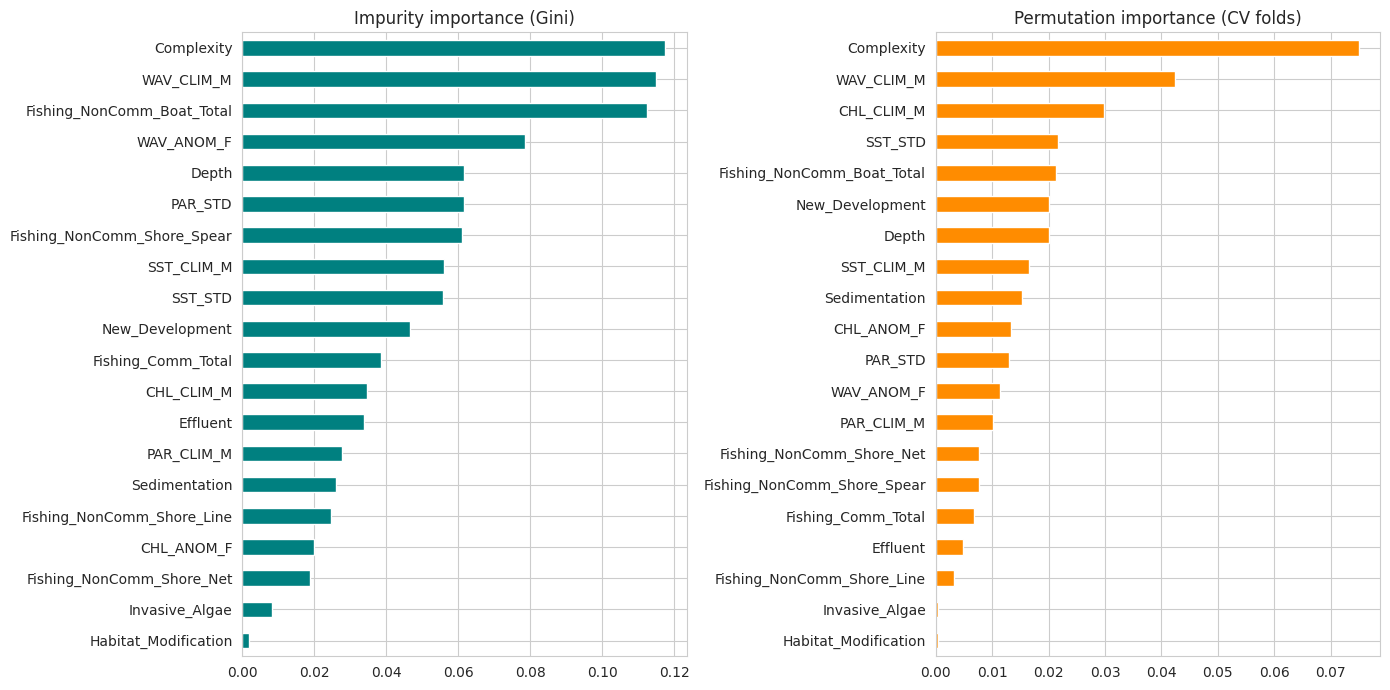

,Gini,Permutation
Complexity,0.1175,0.0750
WAV_CLIM_M,0.1148,0.0423
CHL_CLIM_M,0.0347,0.0298
SST_STD,0.0558,0.0217
Fishing_NonComm_Boat_Total,0.1124,0.0213
New_Development,0.0467,0.0202
Depth,0.0616,0.0201
SST_CLIM_M,0.0560,0.0165
Sedimentation,0.0261,0.0153
CHL_ANOM_F,0.0200,0.0133


In [9]:
imp_gini = pd.Series(final_model.feature_importances_, index=feats)

perm = np.zeros(len(feats))
for tr_idx, va_idx in cv.split(X_tr_final, y_tr):
    m = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **final_gs.best_params_)
    m.fit(X_tr_final.iloc[tr_idx], y_tr.iloc[tr_idx])
    pi = permutation_importance(m, X_tr_final.iloc[va_idx], y_tr.iloc[va_idx],
                                scoring="f1_micro", n_repeats=5, random_state=RANDOM_STATE)
    perm += pi.importances_mean / cv.get_n_splits()
imp_perm = pd.Series(perm, index=feats)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, s, title, col in [(axes[0], imp_gini, "Impurity importance (Gini)", "teal"),
                          (axes[1], imp_perm, "Permutation importance (CV folds)", "darkorange")]:
    s.sort_values().plot.barh(ax=ax, color=col)
    ax.set_title(title)
plt.tight_layout(); plt.show()

top = pd.DataFrame({"Gini": imp_gini, "Permutation": imp_perm}).sort_values("Permutation", ascending=False)
top.head(10).round(4)

## 8. Final evaluation on the held-out test set (n = 124)
The test set is used **once**, with the model chosen from CV alone.

Test micro-F1 : 0.694
Test macro-F1 : 0.683
Test accuracy : 0.694   (identical to micro-F1 for single-label multiclass)

Per-class report:
              precision    recall  f1-score   support

       Reg 1      0.780     0.727     0.753        44
       Reg 2      0.735     0.676     0.704        37
       Reg 3      0.552     0.640     0.593        25
       Reg 5      0.650     0.722     0.684        18

    accuracy                          0.694       124
   macro avg      0.679     0.691     0.683       124
weighted avg      0.702     0.694     0.696       124



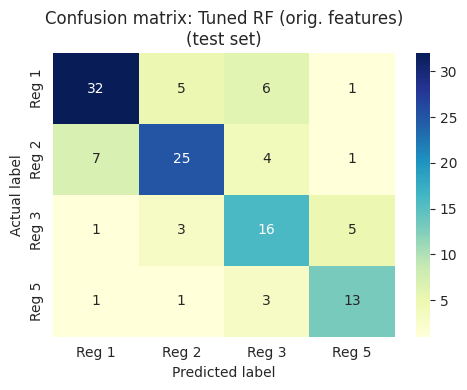

In [10]:
test_pred = final_model.predict(X_te_final)
print("Test micro-F1 : %.3f" % f1_score(y_te, test_pred, average="micro"))
print("Test macro-F1 : %.3f" % f1_score(y_te, test_pred, average="macro"))
print("Test accuracy : %.3f   (identical to micro-F1 for single-label multiclass)" % accuracy_score(y_te, test_pred))
print("\nPer-class report:")
print(classification_report(y_te, test_pred, target_names=CLASS_NAMES, digits=3))
plot_cm(y_te, test_pred, f"Confusion matrix: {final_name}\n(test set)")

## 9. Error analysis and calibration
The paper's logistic model became more accurate as its confidence rose. We check whether the forest does the same, and which regimes it confuses.

In [11]:
cm = confusion_matrix(y_te, test_pred, labels=[1, 2, 3, 5])
recalls = recall_score(y_te, test_pred, average=None, labels=[1, 2, 3, 5])
print("Per-class recall:", {k: round(float(v), 3) for k, v in zip(CLASS_NAMES, recalls)})

errs = sorted([(CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j])) for i in range(4) for j in range(4) if i != j and cm[i, j]],
              key=lambda t: -t[2])
print("\nMost common confusions (actual -> predicted):")
for a, p, n in errs[:5]:
    print(f"  {a} -> {p}: {n}")

# Calibration: accuracy by max-predicted-probability bucket
proba = final_model.predict_proba(X_te_final)
conf = proba.max(axis=1)
correct = (final_model.classes_[proba.argmax(axis=1)] == y_te.values)
bins = pd.cut(conf, bins=[0, 0.4, 0.5, 0.6, 0.7, 1.0])
cal = pd.DataFrame({"conf": conf, "correct": correct, "bin": bins}).groupby("bin", observed=True).agg(
    n=("correct", "size"), accuracy=("correct", "mean"), mean_conf=("conf", "mean")).round(3)
print("\nAccuracy by confidence bucket (test set):")
print(cal)

Per-class recall: {'Reg 1': 0.727, 'Reg 2': 0.676, 'Reg 3': 0.64, 'Reg 5': 0.722}

Most common confusions (actual -> predicted):
  Reg 2 -> Reg 1: 7
  Reg 1 -> Reg 3: 6
  Reg 1 -> Reg 2: 5
  Reg 3 -> Reg 5: 5
  Reg 2 -> Reg 3: 4

Accuracy by confidence bucket (test set):
             n  accuracy  mean_conf
bin                                
(0.0, 0.4]   7     0.143      0.364
(0.4, 0.5]  17     0.235      0.457
(0.5, 0.6]  19     0.684      0.541
(0.6, 0.7]  14     0.786      0.655
(0.7, 1.0]  67     0.851      0.842


## 10. Summary against the paper

In [12]:
summary = comparison.copy()
summary.loc[len(summary)] = ["FINAL: " + final_name + " (test set)", np.nan,
                             f1_score(y_te, test_pred, average="micro"), np.nan,
                             f1_score(y_te, test_pred, average="macro")]
display(summary.round(3))
print("Paper's Random Forest with engineered features: train 1.00 | val 0.70 | test 0.70")

,Model,Train micro-F1,Val micro-F1,Val std,Val macro-F1
0,Default RF (orig. features),1.000,0.679,0.045,0.676
1,Default RF (+ engineered features),1.000,0.679,0.039,0.675
2,Tuned RF (orig. features),0.986,0.692,0.050,0.687
3,Tuned RF (+ engineered features),1.000,0.679,0.039,0.675
4,FINAL: Tuned RF (orig. features) (test set),NaN,0.694,NaN,0.683


Paper's Random Forest with engineered features: train 1.00 | val 0.70 | test 0.70


### Notes
- **Overfitting:** the paper's forest has train F1 = 1.00, so it is fully grown. Our tuned version trades some training score for regularization (`max_depth`, `min_samples_leaf`, `max_features`). Validation scores should be similar either way.
- **Noise:** with 496 training rows and 124 test rows, one test point is about 0.8 F1 points. Differences of 1-3 points between configurations, or between this run and the paper, are not meaningful.
- **Next:** Model 5 (Gradient Boosting) can reuse the loading, CV and plotting cells unchanged.